## main libraries

In [1]:
import torch
from torch import nn

# vision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt


# dataset

In [2]:
training_data=datasets.FashionMNIST(
    root="data", # location 
    train=True, # bool -> for training or test
    download=True,
    transform=ToTensor(), # turning or transforing images PLT -> tensor
    target_transform=None # even output can convet to a tensor
)


testing_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
        

)

In [3]:
image , lable=training_data[100]

# image ---> the actual metrice of the image with PIL tensor format
# lable ---> it is an int that shows which object it is range:[0, len of classs-1]
image.shape , lable
# if [3,h,w] then ---> a 3d cube that z is color of  and rgb but 
#1 means a black and white picture


(torch.Size([1, 28, 28]), 8)

In [4]:
len(training_data)

60000

In [5]:
Label_names=training_data.classes
Label_names.__len__(),Label_names


(10,
 ['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'])

# visual

Text(0.5, 1.0, 'Bag')

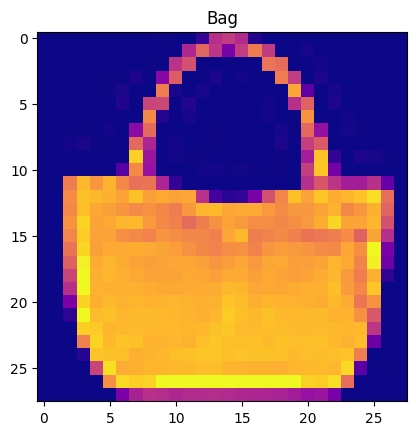

In [6]:
plt.imshow(image.squeeze(),cmap="plasma")
plt.title(Label_names[lable])

## dataloader

In [7]:
from torch.utils.data import DataLoader


BATCH=32 

# spliting datas to ---> small batches
training_dataloader=DataLoader(training_data,
                               batch_size=BATCH,
                               shuffle=True)


testing_dataloader=DataLoader(testing_data,
                               batch_size=BATCH,
                               shuffle=False)

f"{training_dataloader.__len__()} of {BATCH} batches"
    


'1875 of 32 batches'

# model 0

In [8]:
class Fashion(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # converting [height , width] --> [ height * width]
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x) 
# input is 784 ---> 28 * 28
#output is len(lable_class)

model_0=Fashion(input_shape=784,
               hidden_units=10,
               output_shape=10)
model_0.to("cpu")
        

Fashion(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [9]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [10]:
from helper_functions import accuracy_fn

loss_func=nn.CrossEntropyLoss()# need notes for this loss func
optim=torch.optim.SGD(params=model_0.parameters(),
                      lr=0.1)


In [11]:
from tqdm.auto import tqdm
epochs= 4


for epoch in tqdm(range(epochs)):
    train_loss=0
    # trining through batches
    for batch,(X,y) in enumerate(training_dataloader):
        model_0.train()

        y_predict=model_0(X)
        loss=loss_func(y_predict,y)

        train_loss+=loss

        optim.zero_grad()

        loss.backward()

        optim.step()

        if batch % 1000 == 0:
            print(f"Looked at {batch * len(X)}/{len(training_dataloader)} samples")
    train_loss /= len(training_dataloader)
    test_loss,test_acc=0, 0
    
    model_0.eval()
    with torch.inference_mode():
        for X,y in testing_dataloader:
            test_predict=model_0(X)

            test_loss +=loss_func(test_predict,y)
            test_acc +=accuracy_fn(y_true=y, y_pred=test_predict.argmax(dim=1))

            test_loss/= len(testing_dataloader)
            test_acc/= len(testing_dataloader)
            print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")
    

  0%|          | 0/4 [00:00<?, ?it/s]

Looked at 0/1875 samples
Looked at 32000/1875 samples

Train loss: 0.58285 | Test loss: 0.00162, Test acc: 0.24%


Train loss: 0.58285 | Test loss: 0.00157, Test acc: 0.24%


Train loss: 0.58285 | Test loss: 0.00162, Test acc: 0.26%


Train loss: 0.58285 | Test loss: 0.00075, Test acc: 0.30%


Train loss: 0.58285 | Test loss: 0.00168, Test acc: 0.26%


Train loss: 0.58285 | Test loss: 0.00064, Test acc: 0.30%


Train loss: 0.58285 | Test loss: 0.00111, Test acc: 0.29%


Train loss: 0.58285 | Test loss: 0.00232, Test acc: 0.23%


Train loss: 0.58285 | Test loss: 0.00148, Test acc: 0.28%


Train loss: 0.58285 | Test loss: 0.00136, Test acc: 0.26%


Train loss: 0.58285 | Test loss: 0.00133, Test acc: 0.26%


Train loss: 0.58285 | Test loss: 0.00143, Test acc: 0.29%


Train loss: 0.58285 | Test loss: 0.00138, Test acc: 0.28%


Train loss: 0.58285 | Test loss: 0.00106, Test acc: 0.29%


Train loss: 0.58285 | Test loss: 0.00239, Test acc: 0.27%


Train loss: 0.58285 | Test loss: 0.00171, Tes

KeyboardInterrupt: 

### normal nns wont work for picuter inputs as you can see acc is pretty low 
solution ? use CNN

## CNN

In [17]:
class Fashion1(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
  
model=Fashion1(input_shape=1,
              hidden_units=10,
              output_shape=len(Label_names))   
model

Fashion1(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [25]:
optimizer=torch.optim.SGD(params=model.parameters(),
                      lr=0.1)

device="cpu"

In [26]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [29]:

from timeit import default_timer as timer
train_time_start_model_2 = timer()

epochs=3

for epoch in tqdm(range(epochs)):
    train_step(data_loader=training_dataloader,
               model=model,
               loss_fn=loss_func,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device
              )

    test_step(data_loader=testing_dataloader,
               model=model,
               loss_fn=loss_func,
               accuracy_fn=accuracy_fn,
               device=device
             )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device) 

  0%|          | 0/3 [00:00<?, ?it/s]

Train loss: 0.29073 | Train accuracy: 89.41%
Test loss: 0.30984 | Test accuracy: 88.93%

Train loss: 0.28184 | Train accuracy: 89.80%
Test loss: 0.32383 | Test accuracy: 88.17%

Train loss: 0.27601 | Train accuracy: 89.95%
Test loss: 0.31417 | Test accuracy: 88.69%



NameError: name 'print_train_time' is not defined